In [ ]:
import helpers
import numpy as np
import os
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
import torch
from sklearn.metrics import classification_report
import json

In [2]:
# I will simply load the entire dataset into a data loader (for batch processing)
train_dataset_path = r"C:\Users\ayman.mohamed\Personal\Masters_Security\Deep_Learning\CINE_Cardiac_MRI_With_Deep_Learning\CMR-MULTI\CINE_MULTI\4CH_TR\image"
mask_dataset_path = r"C:\Users\ayman.mohamed\Personal\Masters_Security\Deep_Learning\CINE_Cardiac_MRI_With_Deep_Learning\CMR-MULTI\CINE_MULTI\4CH_TR\anno"


all_images = helpers.get_all_np_images(train_dataset_path)
zscaler, clipped_images = helpers.train_scaler(all_images)

test_data_percentage, val_data_percentage = 0.3, 0.3
mri_dataset, test_mri_dataset = helpers.create_2d_dataset(train_dataset_path, mask_dataset_path, scaler=zscaler, test_data_percentage=test_data_percentage)


batch_size = 20
mri_dataloader = DataLoader(mri_dataset, batch_size=batch_size)
test_mri_dataloader = DataLoader(test_mri_dataset, batch_size=batch_size)

classes = list(helpers.load_labels(Problem_Type="CINE", Image_Type="4CH").keys())
print(len(classes))
print(classes)

100%|██████████| 105/105 [00:35<00:00,  2.93it/s]


finished clipping 105 images
finished flattening 105 images to 217025575 pixels
finished training the scaler
All dataset is of length torch.Size([8285, 1, 169, 155]) 
With Masks of torch.Size([8285, 1, 169, 155])
Splitting data to 0.7 for training and 0.3 for testing...
Training with 5800:5800
Testing with 2485:2485
6
[0, 1, 2, 3, 4, 5]


In [3]:
class FCN(nn.Module):
    def __init__(self, in_channels, num_classes):
        """
        FCN with learned transposed convolution upsampling.
        Each decoder stage: ConvTranspose2d (upsample ×2) → Conv2d (refine)
        """
        super(FCN, self).__init__()

        # ── Encoder ──────────────────────────────────────────────────────────
        self.conv1_1 = nn.Conv2d(in_channels, 32,  kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(32,          32,  kernel_size=3, padding=1)
        self.pool1   = nn.MaxPool2d(2, 2)                               # H/2

        self.conv2_1 = nn.Conv2d(32,  64, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(64,  64, kernel_size=3, padding=1)
        self.pool2   = nn.MaxPool2d(2, 2)                               # H/4

        self.conv3_1 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool3   = nn.MaxPool2d(2, 2)                               # H/8

        # ── Bottleneck ───────────────────────────────────────────────────────
        self.conv4_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)

        # ── Decoder stage 1: H/8 → H/4 ──────────────────────────────────────
        # ConvTranspose doubles spatial size; +128 because we concat skip_8x
        self.up1     = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec1_1  = nn.Conv2d(128 + 128, 128, kernel_size=3, padding=1)
        self.dec1_2  = nn.Conv2d(128,       128, kernel_size=3, padding=1)

        # ── Decoder stage 2: H/4 → H/2 ──────────────────────────────────────
        # +64 because we concat skip_4x
        self.up2     = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2_1  = nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1)
        self.dec2_2  = nn.Conv2d(64,      64, kernel_size=3, padding=1)

        # ── Decoder stage 3: H/2 → H ─────────────────────────────────────────
        # No skip here (pool1 features are very shallow, marginal benefit)
        self.up3     = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec3_1  = nn.Conv2d(32, 32, kernel_size=3, padding=1)

        # ── Final classifier head ─────────────────────────────────────────────
        self.classifier = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        orig_size = x.shape[2:]

        # ── Encoder ──────────────────────────────────────────────────────────
        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = self.pool1(x)                   # H/2

        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        skip_4x = x                         # save /4 features for skip
        x = self.pool2(x)                   # H/4

        x = F.relu(self.conv3_1(x))
        x = F.relu(self.conv3_2(x))
        skip_8x = x                         # save /8 features for skip
        x = self.pool3(x)                   # H/8

        # ── Bottleneck ───────────────────────────────────────────────────────
        x = F.relu(self.conv4_1(x))
        x = F.relu(self.conv4_2(x))

        # ── Decoder ──────────────────────────────────────────────────────────
        # Stage 1: learned upsample + concat skip_8x + refine
        x = self.up1(x)                                        # H/8 → H/4
        x = self._match_and_cat(x, skip_8x)                   # handle odd sizes
        x = F.relu(self.dec1_1(x))
        x = F.relu(self.dec1_2(x))

        # Stage 2: learned upsample + concat skip_4x + refine
        x = self.up2(x)                                        # H/4 → H/2
        x = self._match_and_cat(x, skip_4x)
        x = F.relu(self.dec2_1(x))
        x = F.relu(self.dec2_2(x))

        # Stage 3: learned upsample + refine
        x = self.up3(x)                                        # H/2 → H
        x = F.relu(self.dec3_1(x))

        # Final resize handles any residual off-by-one from odd input dims
        x = F.interpolate(x, size=orig_size, mode='bilinear', align_corners=False)

        return self.classifier(x)           # (N, num_classes, H, W)

    @staticmethod
    def _match_and_cat(upsampled, skip):
        """
        Crop or pad upsampled to match skip's spatial size before concat.
        Needed because ConvTranspose2d on odd dimensions can be off by 1px.
        """
        if upsampled.shape[2:] != skip.shape[2:]:
            upsampled = F.interpolate(upsampled, size=skip.shape[2:],
                                      mode='bilinear', align_corners=False)
        return torch.cat([upsampled, skip], dim=1)
    

hist_fcn = {'train_acc': [], 'train_dice': [], 'train_f1': [], 'val_acc': [], 'val_dice': [], 'val_f1': []}

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using {device}")

model = FCN(in_channels=1, num_classes=len(classes)).to(device)
print(model)


class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num_classes = logits.shape[1]

        # Convert logits to probabilities over class dimension
        probs = torch.softmax(logits, dim=1)  # (N, C, H, W)

        # One-hot encode targets: (N, H, W) -> (N, C, H, W)
        targets_one_hot = torch.zeros_like(probs)  # (N, C, H, W)
        targets_one_hot.scatter_(1, targets.unsqueeze(1), 1)  # fill class channels

        # Flatten spatial dims, keep class dim: (N, C, H*W)
        probs = probs.view(probs.shape[0], num_classes, -1)
        targets_one_hot = targets_one_hot.view(targets_one_hot.shape[0], num_classes, -1)

        # Compute Dice per class, then average
        intersection = (probs * targets_one_hot).sum(dim=2)  # (N, C)
        dice = (2. * intersection + self.smooth) / (
            probs.sum(dim=2) + targets_one_hot.sum(dim=2) + self.smooth
        )  # (N, C)

        dice = dice[:, 1:]   # ignore class 0
        return 1 - dice.mean()

# Define the loss function
class_weights = torch.tensor([0.1, 1.0, 1.0, 1.0, 1.0, 1.0], dtype=torch.float).to(device)
ce_loss = nn.CrossEntropyLoss(weight=class_weights)


def combined_loss(logits, targets):
    return ce_loss(logits, targets) + DiceLoss()(logits, targets)

criterion = combined_loss


# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)


num_epochs = 15
for epoch in range(num_epochs):

    # Choose some random batches for validation
    n_samples_val = int(val_data_percentage * len(mri_dataloader))
    random_batch_indices = np.random.randint(0, len(mri_dataloader), n_samples_val // batch_size)
    print(random_batch_indices)

    model.train()
    print(f"Epoch [{epoch + 1}/{num_epochs}]")

    running_loss = 0.0
    total_samples = 0
    train_preds_all = []
    train_targets_all = []

    for batch_index, (data, targets) in enumerate(tqdm(mri_dataloader)):
        data = data.to(device)
        targets = targets.squeeze(1).long().to(device)
        scores = model(data)
        loss = criterion(scores, targets)

        preds = torch.argmax(scores, dim=1)  # (N, H, W)

        # ── Validation batch ────────────────────────────────────────────────
        if batch_index in random_batch_indices:
            # .cpu() before .numpy() — targets/preds may be on GPU
            dice_acc, acc, f1 = helpers.validate(
                targets.cpu().numpy(),
                preds.cpu().numpy(),
                num_classes=len(classes)
            )
            print(f"##########    Validation  dice: {dice_acc:.4f}  acc: {acc:.4f}  f1: {f1:.4f}")
            hist_fcn['val_acc'].append(acc)
            hist_fcn['val_f1'].append(f1)
            hist_fcn['val_dice'].append(dice_acc)
            continue  # skip weight update for this batch

        # ── Training batch ───────────────────────────────────────────────────
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size     = data.size(0)
        running_loss  += loss.item() * batch_size
        total_samples += batch_size

        # Accumulate predictions for epoch-level training metrics
        train_preds_all.append(preds.cpu())
        train_targets_all.append(targets.cpu())

    # ── End-of-epoch training metrics ────────────────────────────────────────
    epoch_loss = running_loss / total_samples
    print(f"Epoch [{epoch + 1}] Loss: {epoch_loss:.4f}")

    # Concatenate all training batches: (total_N, H, W)
    train_preds_np   = torch.cat(train_preds_all).numpy()
    train_targets_np = torch.cat(train_targets_all).numpy()

    train_dice, train_acc, train_f1 = helpers.validate(
        train_targets_np,
        train_preds_np,
        num_classes=len(classes)
    )

    hist_fcn['train_acc'].append(train_acc)
    hist_fcn['train_f1'].append(train_f1)
    hist_fcn['train_dice'].append(train_dice)

    print(f"Epoch [{epoch + 1}] Train - dice: {train_dice:.4f}  acc: {train_acc:.4f}  f1: {train_f1:.4f}")




def evaluate_model(model, dataloader_obj):
    model.eval()
    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for images, labels in dataloader_obj:
            images = images.to(device)
            labels = labels.squeeze(1).long().to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu())
            all_targets.append(labels.cpu())
            #print(torch.unique(preds))

    all_preds   = torch.cat(all_preds).view(-1)
    all_targets = torch.cat(all_targets).view(-1)

    return classification_report(all_targets.numpy(), all_preds.numpy())


using cpu
FCN(
  (conv1_1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1_2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2_1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4_1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4_2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (up1): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
  (dec1_1): Conv2d(

 20%|██        | 59/290 [04:02<12:35,  3.27s/it]

##########    Validation  dice: 0.0000  acc: 0.7858  f1: 0.1467


 33%|███▎      | 97/290 [06:37<10:22,  3.23s/it]

##########    Validation  dice: 0.0000  acc: 0.6947  f1: 0.1415


...

##########    Validation  dice: 0.0043  acc: 0.9329  f1: 0.8371


 53%|█████▎    | 153/290 [12:06<10:04,  4.41s/it]

##########    Validation  dice: 0.0035  acc: 0.9513  f1: 0.8510


100%|██████████| 290/290 [23:27<00:00,  4.85s/it]


Epoch [15] Loss: 0.5995
Epoch [15] Train - dice: 0.4599  acc: 0.9189  f1: 0.8060


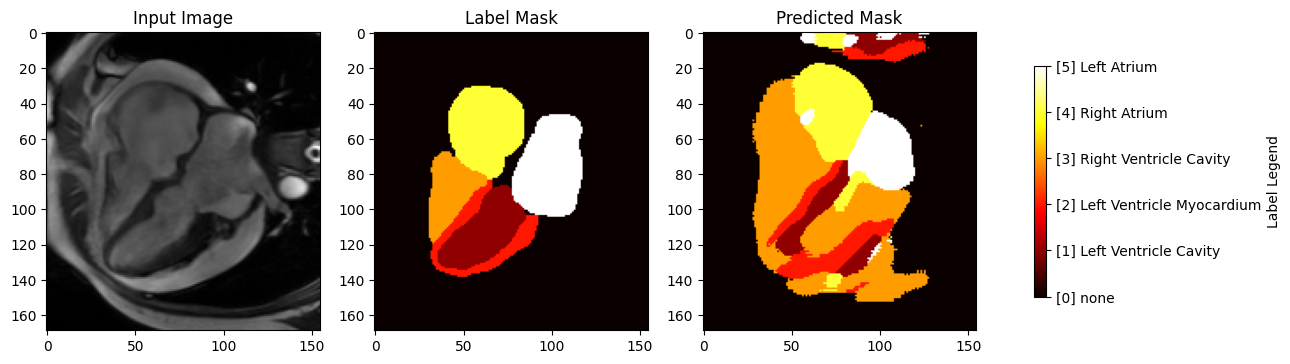

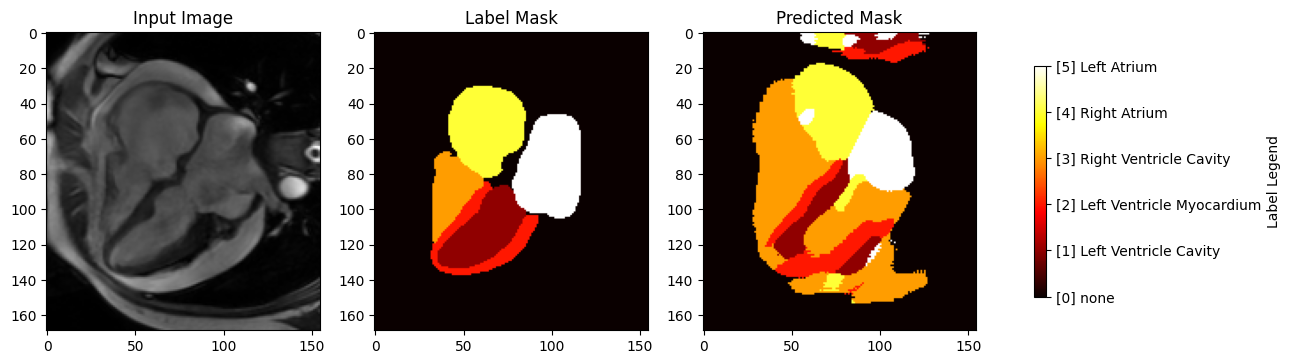

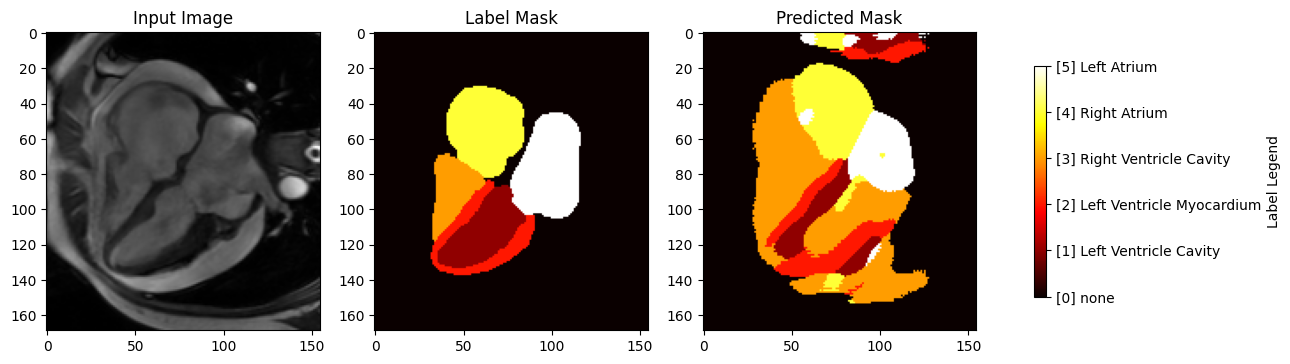

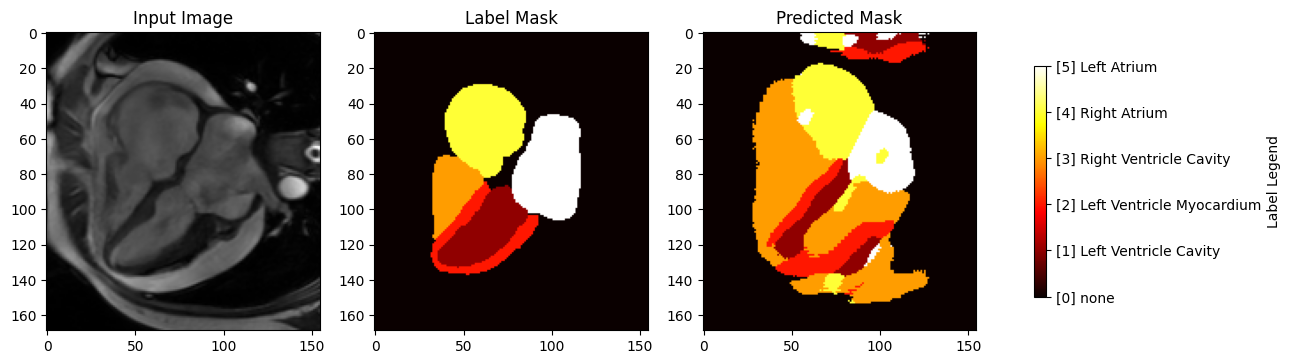

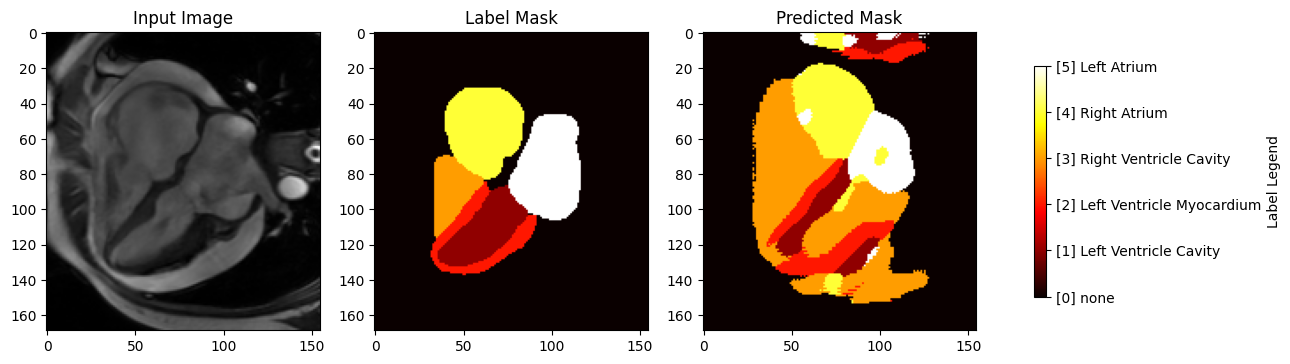

In [5]:
images, masks = next(iter(test_mri_dataloader))

images = images.to(device)
masks = masks.to(device)

masks = masks.squeeze(1).long()

model.eval()
with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)    

images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()


import matplotlib.pyplot as plt

def visualize_sample(img, mask, pred, labels_map):
    figure,axis = plt.subplots(1,3,figsize=(15,10))

    axis[0].imshow(img.squeeze(), cmap='grey')
    axis[0].set_title("Input Image")

    Plot_Color_Op = axis[1].imshow(mask, cmap='hot')
    axis[1].set_title("Label Mask")

    axis[2].imshow(pred, cmap='hot')
    axis[2].set_title("Predicted Mask")

    cbar = figure.colorbar(Plot_Color_Op, ax=axis.ravel().tolist(), shrink=0.3, ticks=list(labels_map.keys()), label='Label Legend')
    cbar.ax.set_yticklabels(list(labels_map.values()))

labelled_classes = helpers.load_labels(Problem_Type="CINE", Image_Type="4CH")
for i in range(5):  # change number as you like
    visualize_sample(images[i], masks[i], preds[i], labelled_classes)





In [ ]:
# new_hist_fcn = {}
# for k, v in hist_fcn.items():
#     if(type(hist_fcn[k]) == list):
#         sum=0
#         cnt=0
#         epoch_sums = {}
#         epoch_counts = {}
#         for epoch_num, acc_score in hist_fcn[k]:
#             if epoch_num in epoch_sums.keys():
#                 epoch_sums[epoch_num] += acc_score
#                 epoch_counts[epoch_num] += 1
#             else:
#                 epoch_sums[epoch_num] = acc_score
#                 epoch_counts[epoch_num] = 1
            
#         for epoch_number in epoch_sums.keys():
#             new_hist_fcn[k][epoch_number] = epoch_sums[epoch_number] / epoch_counts[epoch_number]



def average_by_epoch(metrics_dict):
    result = {}

    for metric, values in metrics_dict.items():
        epoch_sums = {}
        epoch_counts = {}

        # accumulate sums and counts
        for epoch, score in values:
            epoch_sums[epoch] += score
            epoch_counts[epoch] += 1

        # compute averages
        averaged = []
        for epoch in sorted(epoch_sums.keys()):
            avg = epoch_sums[epoch] / epoch_counts[epoch]
            averaged.append((epoch, avg))

        result[metric] = averaged

    return result


hist_fcn = average_by_epoch(hist_fcn)
with open("hist_fcn.json", "w") as f:
    json.dump(hist_fcn, f, indent=4)